In [1]:
import torch
import torch.nn as nn
import pandas as pd
import torchvision
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader,random_split
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt

In [2]:
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
class_to_idx = {cls: idx for idx, cls in enumerate(CLASS_NAMES)}

In [3]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

In [4]:
class DatasetLoad(Dataset):

    def __init__(self,csv_file,image_file,transform = None):
        self.data =  pd.read_csv(csv_file)
        self.image = image_file
        self.transform =  transform

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self,idx):
        img_name = self.data.iloc[idx]["image_id"] + ".jpg"
        img_path = os.path.join(self.image, img_name)
        image = Image.open(img_path).convert("RGB")

        label_str =  self.data.iloc[idx]["dx"]
        label =  class_to_idx[label_str]

        if self.transform:
            image = self.transform(image)
        return image,torch.tensor(label,dtype = torch.long)


In [5]:
full_dataset  = DatasetLoad(
        csv_file ='D:\Skin cancer Using pytorch\HAM10000_metadata.csv',
        image_file ='D:\Skin cancer Using pytorch\HAM10000_images',
        transform  =  transform
)

In [6]:
train_size = int(0.8 * len(full_dataset))
# int(0.8 * 10015) = int(8012.0) = 8012
test_size = len(full_dataset) - train_size
# 10015 - 8012 = 2003

In [ ]:
fig,axes  =  plt.subplots(figsize = (10,10))

fig.subtitle("Images")

for i , ax in enuma

In [7]:
train_data, test_data = random_split(full_dataset, [train_size, test_size])

train_dataloader = DataLoader(train_data, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=16, shuffle=False)

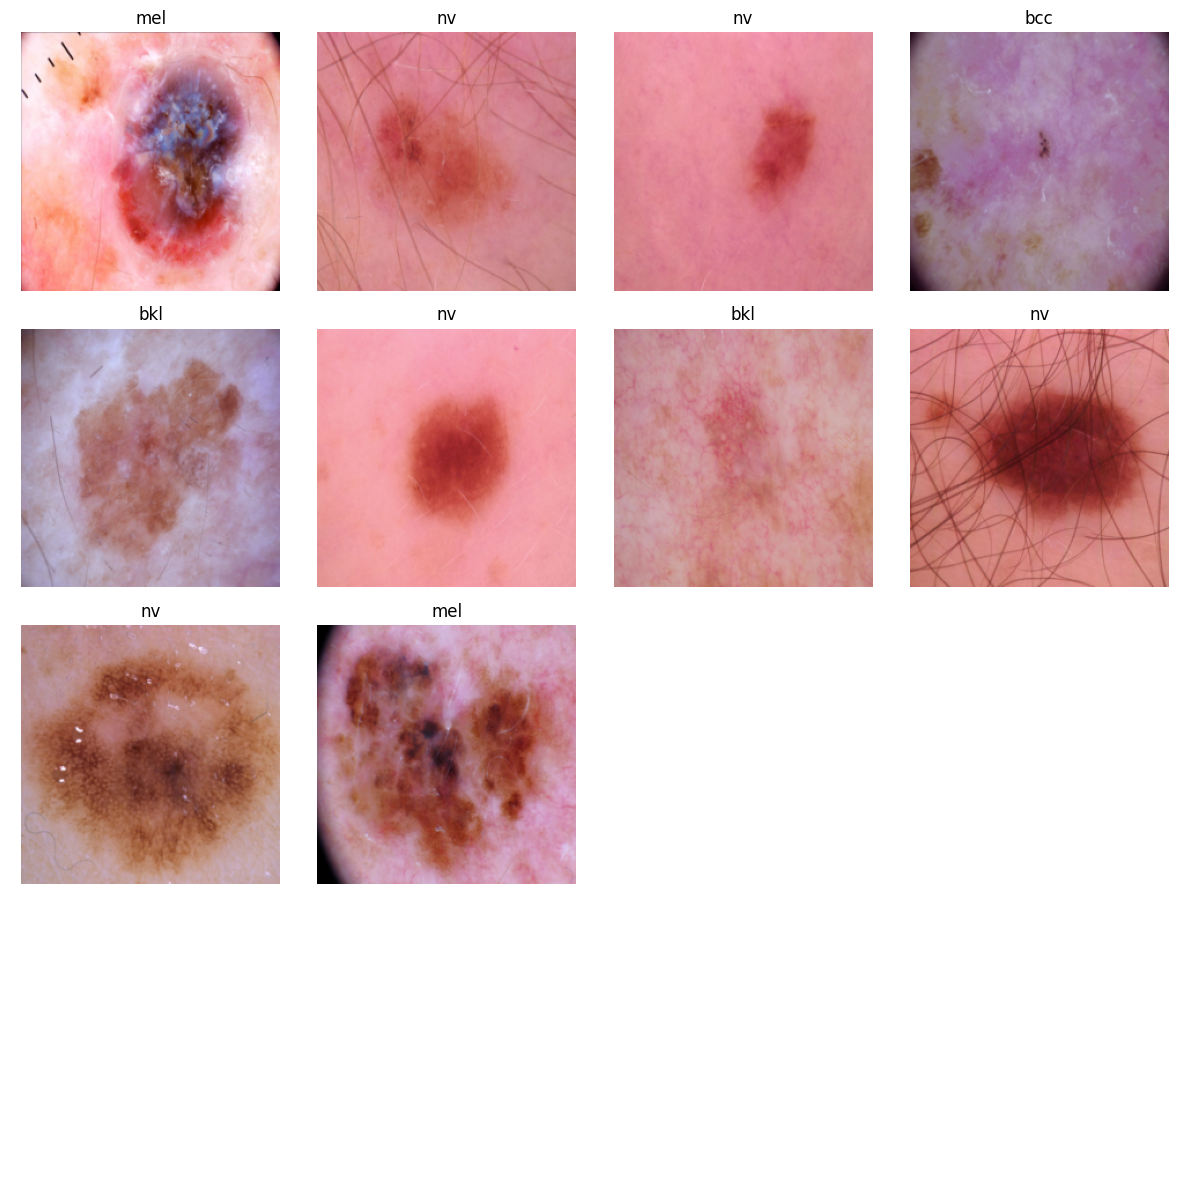

In [ ]:
import random

# Randomly sample 16 images from the dataset, undo the normalization for display,
# and plot them in a 4x4 grid with class labels as titles.
def unnormalize_image(tensor_img):
    mean = torch.tensor([0.485, 0.456, 0.406], dtype=tensor_img.dtype, device=tensor_img.device)
    std = torch.tensor([0.229, 0.224, 0.225], dtype=tensor_img.dtype, device=tensor_img.device)
    img = tensor_img * std[:, None, None] + mean[:, None, None]
    return img.clamp(0, 1)

random_indices = random.sample(range(len(full_dataset)), 16)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle("Random 16 images from HAM10000", fontsize=16)

for ax, idx in zip(axes.flatten(), random_indices):
    img, label = full_dataset[idx]
    img = unnormalize_image(img)
    ax.imshow(img.permute(1, 2, 0).cpu().numpy())
    ax.set_title(CLASS_NAMES[label.item()], fontsize=8)
    ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Custom CNN model


In [9]:
class cnnModel(nn.Module):
    def __init__(self,num_classes=7):
        super ().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,kernel_size =3 , padding = 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32,64,kernel_size =3 , padding = 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64,128,kernel_size =3 , padding = 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )
        self.classification = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28,512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,num_classes)
        )
    def forward(self,x):
        x = self.features(x)
        x = self.classification(x)
        return x
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
        


Using device: cuda


In [10]:
model = cnnModel(num_classes=7).to(device)

In [11]:
print(next(model.parameters()).device)  # must say cuda:0 before training

cuda:0


In [12]:
optimizer  = optim.Adam(model.parameters(),lr = 0.001)
criterion = nn.CrossEntropyLoss()
for epoch in range(7):
    model.train()
    total_loss = 0

    for image,labels in train_dataloader:
        image =  image.to(device)
        label = labels.to(device)
        optimizer.zero_grad()
        outputs = model(image)
        loss =  criterion(outputs,label)
        loss.backward()``
        optimizer.step()

        total_loss += loss.item()


    avg_loss  = total_loss/len(train_dataloader)
    print(f"Epoch{epoch}  || Loss:{avg_loss}")


Epoch0  || Loss:2.55302621034567
Epoch1  || Loss:1.065497719301673
Epoch2  || Loss:0.9896520877074815
Epoch3  || Loss:0.981191136582407
Epoch4  || Loss:0.9330128062509015
Epoch5  || Loss:0.8976894778286864
Epoch6  || Loss:0.8418760588188133


In [13]:
model.eval()
correct = 0
total = 0

In [16]:

with torch.no_grad():
    for image,labels in test_dataloader:
        image =  image.to(device)
        labels = labels.to(device)
        outputs = model(image)
        _,predicted = torch.max(outputs,1)
        total +=labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Accuracy {correct/total}")

Accuracy 0.7199201198202696


Now using transferLearning To improve the accuracy here